In [24]:
import pandas as pd

from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score

import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
data_train = pd.read_csv("snapfood_train.csv")
data_train

,comment,label,label_id
0,غذا خیلی سرد بود در صورتیکه فاصله ما خیلی کم است,SAD,1.0
1,بهتره بتونیم ران یا سینه رو خودمون انتخاب کنیم,HAPPY,0.0
2,غذا بد بود حالم خیییییلی بده. دل دردو دل پیچه....,SAD,1.0
3,با سلام سابق بر این بسته بندی از کیفیت بهتری ب...,SAD,1.0
4,سلام، خیلی ممنون و متشکرم,HAPPY,0.0
...,...,...,...
52105,یکی از بهترین ته چین هاییه که خوردم,HAPPY,0.0
52106,به موقع و خوب دستتون درد نکنه,HAPPY,0.0
52107,خیلی تازه و خوشمزه بود. بسته بندی شیک وعالی. خ...,HAPPY,0.0
52108,فوق العاده سریع و عالی واقعا واسه همه زود آورد...,HAPPY,0.0


In [26]:
x = data_train["comment"]
y = data_train["label"]

In [37]:
tf = TfidfVectorizer(ngram_range=(1,4), max_df=0.98)

x_transformed = tf.fit_transform(x)
x_transformed

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3318458 stored elements and shape (52110, 1559120)>

In [38]:
model = LinearSVC()

model.fit(x_transformed, y)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [39]:
text = "سلام عالی بود"

text_transformed = tf.transform([text])

model.predict(text_transformed)

array(['HAPPY'], dtype=object)

In [40]:
data = pd.read_csv("snapfood_test.csv")
data

,comment,label,label_id
0,استرس داشتم نکنه که به خاطر تخفیف از کیفیت پای...,HAPPY,0.0
1,قاشق و نمک نداشت,HAPPY,0.0
2,سس مخصوص ساده‌ترین سس مایونزی بود که میشد تصور...,SAD,1.0
3,به جای شامپو. نرم کننده اوردن,SAD,1.0
4,یک غذای خوب وسالم ممنون,SAD,1.0
...,...,...,...
9028,بعضی از تیکه‌ها تند بود و در منو قید نشده بود....,SAD,1.0
9029,پیتزا گوشت و قارچ سفارش داده شده و نصف پیتزا ک...,SAD,1.0
9030,عالی بود سریع ویخ زده,HAPPY,0.0
9031,غذای خوبی بود نسبت به قیمتش,HAPPY,0.0


In [41]:
data.rename(columns={"label": "truth"}, inplace=True)

In [42]:
x_test = data["comment"]

x_test = tf.transform(x_test)
p = model.predict(x_test)

data["prediction"] = p

data

,comment,truth,label_id,prediction
0,استرس داشتم نکنه که به خاطر تخفیف از کیفیت پای...,HAPPY,0.0,SAD
1,قاشق و نمک نداشت,HAPPY,0.0,SAD
2,سس مخصوص ساده‌ترین سس مایونزی بود که میشد تصور...,SAD,1.0,SAD
3,به جای شامپو. نرم کننده اوردن,SAD,1.0,SAD
4,یک غذای خوب وسالم ممنون,SAD,1.0,HAPPY
...,...,...,...,...
9028,بعضی از تیکه‌ها تند بود و در منو قید نشده بود....,SAD,1.0,SAD
9029,پیتزا گوشت و قارچ سفارش داده شده و نصف پیتزا ک...,SAD,1.0,SAD
9030,عالی بود سریع ویخ زده,HAPPY,0.0,HAPPY
9031,غذای خوبی بود نسبت به قیمتش,HAPPY,0.0,HAPPY


In [43]:
data.to_excel("predictions.xlsx", index=False)

#MIN98

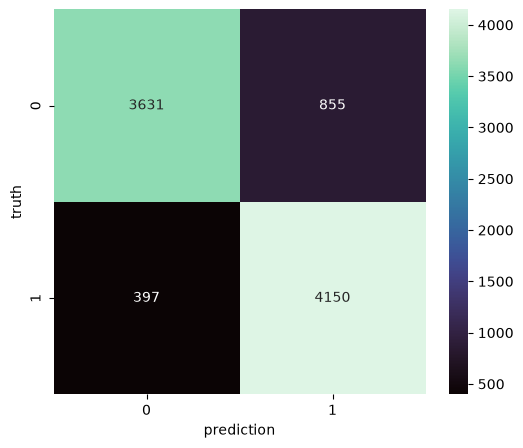

Accuracy: 0.8613970995239677
Precision for each class: [0.90143992 0.82917083]


In [44]:



cm = confusion_matrix(
    data["truth"],
    data["prediction"]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="mako"
)

plt.xlabel("prediction")
plt.ylabel("truth")

plt.show()



acc = accuracy_score(
    data["truth"],
    data["prediction"]
)

print("Accuracy:", acc)



precision = precision_score(
    data["truth"],
    data["prediction"],
    average=None
)

print("Precision for each class:", precision)

min99

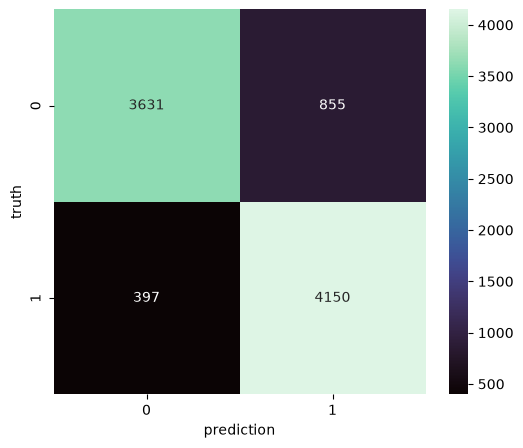

Accuracy: 0.8613970995239677
Precision for each class: [0.90143992 0.82917083]


In [20]:
cm = confusion_matrix(
    data["truth"],
    data["prediction"]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="mako"
)

plt.xlabel("prediction")
plt.ylabel("truth")

plt.show()



acc = accuracy_score(
    data["truth"],
    data["prediction"]
)

print("Accuracy:", acc)



precision = precision_score(
    data["truth"],
    data["prediction"],
    average=None
)

print("Precision for each class:", precision)

ngram6

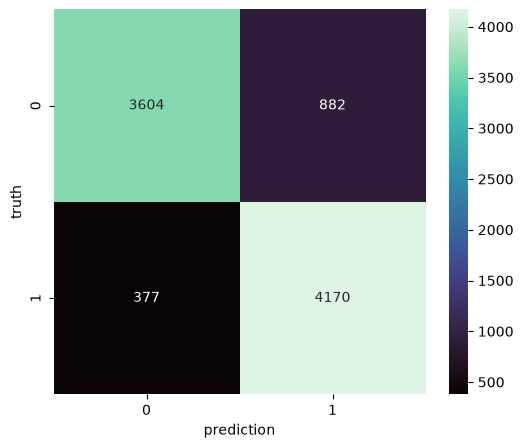

Accuracy: 0.8606221631794532
Precision for each class: [0.90530018 0.82541568]


In [35]:



cm = confusion_matrix(
    data["truth"],
    data["prediction"]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="mako"
)

plt.xlabel("prediction")
plt.ylabel("truth")

plt.show()



acc = accuracy_score(
    data["truth"],
    data["prediction"]
)

print("Accuracy:", acc)



precision = precision_score(
    data["truth"],
    data["prediction"],
    average=None
)

print("Precision for each class:", precision)